In [ ]:
# preprocessing pada dataset komentar dan pembuatan TF-IDF

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from google.colab import drive
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download data tokenisasi punkt dari NLTK
nltk.download('punkt')
nltk.download('stopwords')

drive.mount('/content/gdrive')

# Path file CSV yang telah dipreprocess
preprocessed_file_path = '/content/gdrive/MyDrive/modelling/preprocessed_data.csv'

# Memuat DataFrame yang telah dipreprocess
df = pd.read_csv(preprocessed_file_path)

# Menangani nilai NaN dengan menghapus baris yang mengandung nilai NaN
df = df.dropna(subset=['comment'])

# Menggantikan nilai NaN dengan string kosong pada kolom 'comment'
df['comment'] = df['comment'].fillna('')

# Inisialisasi objek TF-IDF Vectorizer
daftar_stopword = stopwords.words('indonesian')
# Tokenisasi stop words dengan menggunakan word_tokenize
daftar_stopword_tokens = set(word_tokenize(" ".join(daftar_stopword)))

# Penambahana Stopwords
daftar_stopword_tokens.update(['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'])

tfidf_vectorizer = TfidfVectorizer(stop_words=list(daftar_stopword_tokens))

# Menggunakan TF-IDF Vectorizer pada kolom 'comment'
tfidf_matrix = tfidf_vectorizer.fit_transform(df['comment'])

# Normalisasi matriks TF-IDF
tfidf_matrix_normalized = normalize(tfidf_matrix, norm='l2', axis=1)

# Membuat DataFrame baru dari matriks TF-IDF
tfidf_df = pd.DataFrame(tfidf_matrix_normalized.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Menampilkan beberapa baris pertama dari DataFrame hasil TF-IDF
print("Beberapa baris pertama dari DataFrame hasil TF-IDF:")
print(tfidf_df.head())

# Menyimpan DataFrame hasil TF-IDF ke file CSV di Google Drive
tfidf_output_file_path = '/content/gdrive/MyDrive/modelling/tfidf_matrix.csv'
tfidf_df.to_csv(tfidf_output_file_path, index=False)

# Menampilkan pesan bahwa data TF-IDF berhasil disimpan
print(f"Data TF-IDF berhasil disimpan ke: {tfidf_output_file_path}")

# Menampilkan jumlah baris dan kolom DataFrame sebelum dan sesudah TF-IDF
print("\nJumlah Baris dan Kolom Sebelum TF-IDF:", df.shape)
print("Jumlah Baris dan Kolom Setelah TF-IDF:", tfidf_df.shape)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Beberapa baris pertama dari DataFrame hasil TF-IDF:
   aal  aan  abdetnya  abhishek  abisin  abu  acara  action  adakan  \
0  0.0  0.0       0.0       0.0     0.0  0.0    0.0     0.0     0.0   
1  0.0  0.0       0.0       0.0     0.0  0.0    0.0     0.0     0.0   
2  0.0  0.0       0.0       0.0     0.0  0.0    0.0     0.0     0.0   
3  0.0  0.0       0.0       0.0     0.0  0.0    0.0     0.0     0.0   
4  0.0  0.0       0.0       0.0     0.0  0.0    0.0     0.0     0.0   

   adakecewa  ...  yuttuber  yutube  yutuber  yutubkids  yutup  yuwtup   yy  \
0        0.0  ...       0.0     0.0      0.0        0.0    0.0     0.0  0.0   
1        0.0  ...       0.0     0.0      0.0        0.0    0.0     0.0  0.0   
2        0.0  ...       0.0     0.0      0.0        0.0    0.0     0.0  0.0   
3        0.0  ...       0.0     0.0      0.0        0.0    0.0     0.0  0.

In [ ]:
#Menggunakan Cosine Similarity Langsung pada Matriks TF-IDF

from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
from google.colab import drive

drive.mount('/content/gdrive')

# Path file CSV matriks TF-IDF
tfidf_matrix_path = '/content/gdrive/MyDrive/modelling/tfidf_matrix.csv'

# Memuat DataFrame matriks TF-IDF
tfidf_df = pd.read_csv(tfidf_matrix_path)

# Mencari indeks kolom-kolom yang sesuai dengan kata kunci "atur", "konten", dan "kecewa"
indeks_atur = tfidf_df.columns.get_loc('atur')
indeks_konten = tfidf_df.columns.get_loc('konten')
indeks_kecewa = tfidf_df.columns.get_loc('kecewa')

# Membuat matriks kata kunci dengan dimensi yang sesuai
tfidf_atur = tfidf_df.copy()
tfidf_atur.iloc[:, :] = 0
tfidf_atur.iloc[:, indeks_atur] = 1

tfidf_konten = tfidf_df.copy()
tfidf_konten.iloc[:, :] = 0
tfidf_konten.iloc[:, indeks_konten] = 1

tfidf_kecewa = tfidf_df.copy()
tfidf_kecewa.iloc[:, :] = 0
tfidf_kecewa.iloc[:, indeks_kecewa] = 1

# Menghitung cosine similarity antara dua dokumen
similarity_score_atur = cosine_similarity(tfidf_atur, tfidf_df)
similarity_score_konten = cosine_similarity(tfidf_konten, tfidf_df)
similarity_score_kecewa = cosine_similarity(tfidf_kecewa, tfidf_df)

# Menentukan jumlah kata yang akan ditampilkan pada output
jumlah_kata_tampil = 5

# Mendapatkan indeks lima kata dengan cosine similarity tertinggi untuk kata kunci 'atur'
indeks_top_kata_atur = similarity_score_atur[0].argsort()[-jumlah_kata_tampil:][::-1]

# Mendapatkan indeks lima kata dengan cosine similarity tertinggi untuk kata kunci 'konten'
indeks_top_kata_konten = similarity_score_konten[0].argsort()[-jumlah_kata_tampil:][::-1]

# Mendapatkan indeks lima kata dengan cosine similarity tertinggi untuk kata kunci 'kecewa'
indeks_top_kata_kecewa = similarity_score_kecewa[0].argsort()[-jumlah_kata_tampil:][::-1]

# Menampilkan lima kata teratas untuk kata kunci 'atur' beserta cosine similarity score-nya
print("\nTop 5 kata untuk kata kunci 'atur':")
for indeks in indeks_top_kata_atur:
    print(f"'{tfidf_df.columns[indeks]}': {similarity_score_atur[0][indeks]:.3f}")

# Menampilkan lima kata teratas untuk kata kunci 'konten' beserta cosine similarity score-nya
print("\nTop 5 kata untuk kata kunci 'konten':")
for indeks in indeks_top_kata_konten:
    print(f"'{tfidf_df.columns[indeks]}': {similarity_score_konten[0][indeks]:.3f}")

# Menampilkan lima kata teratas untuk kata kunci 'kecewa' beserta cosine similarity score-nya
print("\nTop 5 kata untuk kata kunci 'kecewa':")
for indeks in indeks_top_kata_kecewa:
    print(f"'{tfidf_df.columns[indeks]}': {similarity_score_kecewa[0][indeks]:.3f}")


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


<ipython-input-11-9f2bf8eea1c0>:22: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  tfidf_atur.iloc[:, indeks_atur] = 1
<ipython-input-11-9f2bf8eea1c0>:26: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  tfidf_konten.iloc[:, indeks_konten] = 1
<ipython-input-11-9f2bf8eea1c0>:30: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`


Top 5 kata untuk kata kunci 'atur':
'cerita': 0.703
'bagussebagai': 0.615
'handphone': 0.582
'agama': 0.564
'action': 0.552

Top 5 kata untuk kata kunci 'konten':
'goodnamazing': 0.648
'debes': 0.642
'menyesatkanyang': 0.613
'lebar': 0.610
'audience': 0.609

Top 5 kata untuk kata kunci 'kecewa':
'keras': 1.000
'aktifivas': 0.885
'fawzia': 0.735
'agama': 0.731
'murni': 0.624


In [ ]:
# Menyimpan hasil Cosine Similarity Score ke file CSV
hasil_similarity_path = '/content/gdrive/MyDrive/modelling/hasil_cosine_similarity.csv'

# Membuat DataFrame untuk menyimpan hasil
hasil_similarity_df = pd.DataFrame({
    'Cosine Similarity Score atur': similarity_score_atur[0],
    'Cosine Similarity Score konten': similarity_score_konten[0],
    'Cosine Similarity Score kecewa': similarity_score_kecewa[0],
})

# Menyimpan DataFrame ke file CSV
hasil_similarity_df.to_csv(hasil_similarity_path, index=False)

# Menampilkan pesan bahwa hasil Cosine Similarity Score berhasil disimpan
print(f"Hasil Cosine Similarity Score berhasil disimpan ke: {hasil_similarity_path}")


Hasil Cosine Similarity Score berhasil disimpan ke: /content/gdrive/MyDrive/modelling/hasil_cosine_similarity.csv


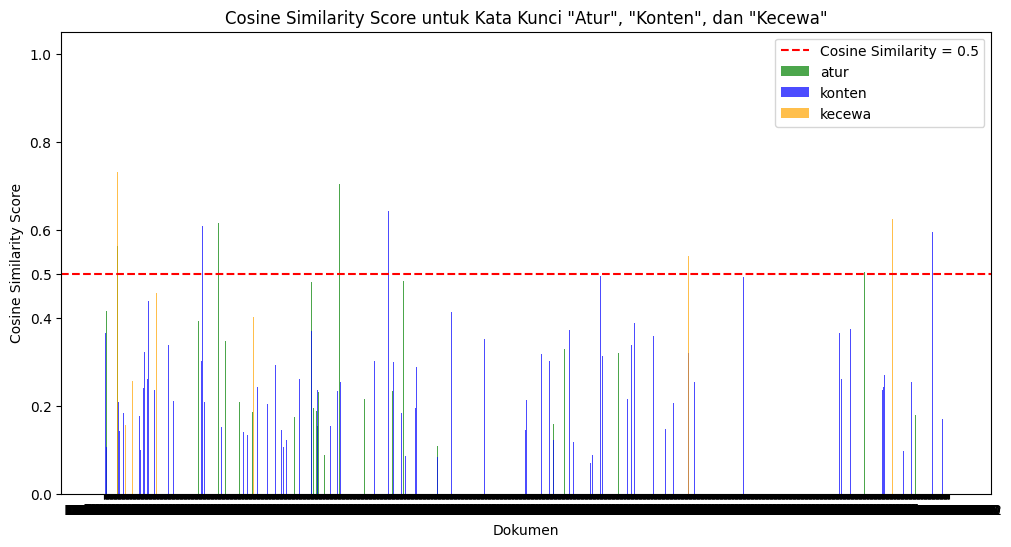

In [ ]:
import matplotlib.pyplot as plt

# Visualisasi hasil Cosine Similarity Score
plt.figure(figsize=(12, 6))

# Plot bar untuk skor kemiripan kata kunci 'atur'
plt.bar(range(len(similarity_score_atur[0])), similarity_score_atur[0], label='atur', color='green', alpha=0.7)

# Plot bar untuk skor kemiripan kata kunci 'konten'
plt.bar(range(len(similarity_score_konten[0])), similarity_score_konten[0], label='konten', color='blue', alpha=0.7)

# Plot bar untuk skor kemiripan kata kunci 'kecewa'
plt.bar(range(len(similarity_score_kecewa[0])), similarity_score_kecewa[0], label='kecewa', color='orange', alpha=0.7)

# Tambahkan garis referensi pada nilai cosine similarity 0.5
plt.axhline(y=0.5, color='red', linestyle='--', label='Cosine Similarity = 0.5')

# Tambahkan label pada sumbu x
plt.xticks(range(len(similarity_score_atur[0])), [f'Dokumen {i+1}' for i in range(len(similarity_score_atur[0]))])

# Tambahkan label pada sumbu y
plt.yticks([0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0])

# Tambahkan label dan judul
plt.xlabel('Dokumen')
plt.ylabel('Cosine Similarity Score')
plt.title('Cosine Similarity Score untuk Kata Kunci "Atur", "Konten", dan "Kecewa"')

# Tampilkan legenda
plt.legend()

# Tampilkan plot
plt.show()
